In [1]:
import pandas as pd

df = pd.read_csv("https://github.com/ellimilial/clinical-trials-negative-efficacy/raw/refs/heads/main/02-negative-efficacy-prediction.csv.zip")
# df = pd.read_csv("02-negative-efficacy-prediction.csv.zip")
df.describe(include="all")

,nct_id,brief_title,official_title,overall_status,start_date,completion_date,study_type,phase,why_stopped,condition_name,intervention_name,intervention_type,y_prob,y_pred,argmax_pred,decision_threshold,predicted_label,argmax_label
count,172675,172675,171666,172675,171475,166317,172675,116320,172675,172675,172675,172675,172675.000000,172675.000000,172675.000000,1.726750e+05,172675,172675
unique,42821,42771,42283,3,4853,4657,2,7,31119,22562,48779,11,NaN,NaN,NaN,NaN,2,2
top,NCT03878524,Serial Measurements of Molecular and Architect...,Serial Measurements of Molecular and Architect...,TERMINATED,2020-04-01,2020-12-10,INTERVENTIONAL,PHASE2,Low accrual,Breast Cancer,Placebo,DRUG,NaN,NaN,NaN,NaN,not_negative_efficacy,not_negative_efficacy
freq,2800,2800,2800,116491,2875,2832,161802,41529,3851,1820,6352,85084,NaN,NaN,NaN,NaN,161650,161973
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.062359,0.063848,0.061978,1.040404e-01,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.239914,0.244483,0.241116,2.775566e-17,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000081,0.000000,0.000000,1.040404e-01,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000093,0.000000,0.000000,1.040404e-01,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000101,0.000000,0.000000,1.040404e-01,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000123,0.000000,0.000000,1.040404e-01,NaN,NaN


In [2]:
print("Predicted negative:", df[df.predicted_label == 'negative_efficacy'].nct_id.nunique())
print(" - before 2021-11-07:", df[(df.predicted_label == 'negative_efficacy') & (df.completion_date < '2021-11-07')].nct_id.nunique())


Predicted negative: 3042
 - before 2021-11-07: 2136


In [3]:
df_ot = pd.read_csv("https://raw.githubusercontent.com/opentargets/stopReasons/refs/heads/main/data/predictions_stop.tsv", sep="\t")
print("Total clinical trials predicted to be stopped as Negative in OT work: ", df_ot[df_ot.prediction == "Negative"].nct_id.nunique())

df_ot.describe(include='all')


Total clinical trials predicted to be stopped as Negative in OT work:  1966


,nct_id,phase,why_stopped,pmid,prediction
count,376057,165405,27414,1.236240e+05,27414
unique,376057,7,20303,NaN,21
top,NCT04244214,Phase 2,Slow accrual,NaN,Insufficient Enrollment
freq,1,48238,193,NaN,9585
mean,NaN,NaN,NaN,2.330800e+07,NaN
std,NaN,NaN,NaN,7.296955e+06,NaN
min,NaN,NaN,NaN,1.000000e+00,NaN
25%,NaN,NaN,NaN,1.885282e+07,NaN
50%,NaN,NaN,NaN,2.433128e+07,NaN
75%,NaN,NaN,NaN,2.921997e+07,NaN


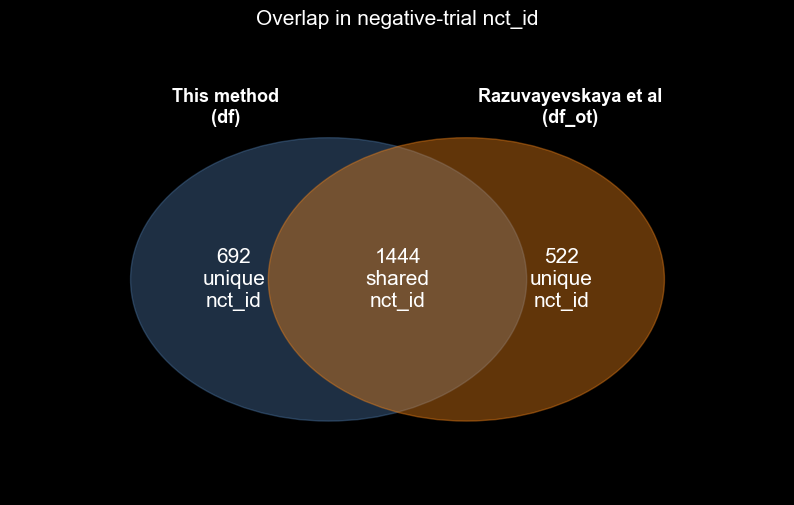

df negative trials before 2021-11-07: 2136
df_ot negative trials: 1966
Unique nct_id in df only: 692
Shared nct_id: 1444
Unique nct_id in df_ot only: 522


In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

df_negative = df[(df.predicted_label == 'negative_efficacy') & (df.completion_date < '2021-11-07')].copy()
df_ot_negative = df_ot[df_ot.prediction == 'Negative'].copy()

df_nct_ids = set(df_negative['nct_id'].dropna())
df_ot_nct_ids = set(df_ot_negative['nct_id'].dropna())

df_only_nct_ids = df_nct_ids - df_ot_nct_ids
shared_nct_ids = df_nct_ids & df_ot_nct_ids
df_ot_only_nct_ids = df_ot_nct_ids - df_nct_ids

fig, ax = plt.subplots(figsize=(10, 6))
left = Circle((0.42, 0.5), 0.23, color='#4C78A8', alpha=0.4)
right = Circle((0.58, 0.5), 0.23, color='#F58518', alpha=0.4)
ax.add_patch(left)
ax.add_patch(right)
ax.text(0.30, 0.78, 'This method\n(df)', ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(0.70, 0.78, 'Razuvayevskaya et al\n(df_ot)', ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(0.31, 0.50, f'{len(df_only_nct_ids)}\nunique\nnct_id', ha='center', va='center', fontsize=15)
ax.text(0.50, 0.50, f'{len(shared_nct_ids)}\nshared\nnct_id', ha='center', va='center', fontsize=15)
ax.text(0.69, 0.50, f'{len(df_ot_only_nct_ids)}\nunique\nnct_id', ha='center', va='center', fontsize=15)
ax.set_title('Overlap in negative-trial nct_id', fontsize=15)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0.15, 0.9)
ax.axis('off')
plt.show()

print('df negative trials before 2021-11-07:', len(df_nct_ids))
print('df_ot negative trials:', len(df_ot_nct_ids))
print('Unique nct_id in df only:', len(df_only_nct_ids))
print('Shared nct_id:', len(shared_nct_ids))
print('Unique nct_id in df_ot only:', len(df_ot_only_nct_ids))

df_negative_shared = df_negative[df_negative['nct_id'].isin(shared_nct_ids)].copy()
df_ot_negative_shared = df_ot_negative[df_ot_negative['nct_id'].isin(shared_nct_ids)].copy()


In [6]:
from IPython.display import display

pd.set_option('display.max_colwidth', None)

def sample_nct_examples(source_df, nct_ids, columns, n=50):
    subset = source_df[source_df['nct_id'].isin(nct_ids)].copy()
    subset = subset.drop_duplicates('nct_id')
    return subset[columns].head(n)

def sample_shared_examples(df_source, df_ot_source, nct_ids, n=50):
    left = sample_nct_examples(
        df_source,
        nct_ids,
        ['nct_id', 'brief_title', 'why_stopped'],
        n=n
    ).rename(columns={'why_stopped': 'why_stopped_df'})
    right = sample_nct_examples(
        df_ot_source,
        nct_ids,
        ['nct_id', 'why_stopped', 'prediction'],
        n=n
    ).rename(columns={'why_stopped': 'why_stopped_df_ot'})
    return left.merge(right, on='nct_id', how='inner').head(n)

print('Examples unique to df negative nct_id (this method):')
display(sample_nct_examples(
    df_negative,
    df_only_nct_ids,
    ['nct_id', 'brief_title', 'why_stopped']
))

print('\nExamples in shared negative nct_id:')
display(sample_shared_examples(
    df_negative_shared,
    df_ot_negative_shared,
    shared_nct_ids
))

print('\nExamples unique to df_ot negative nct_id (Razuvayevskaya et al):')
display(sample_nct_examples(
    df_ot_negative,
    df_ot_only_nct_ids,
    ['nct_id', 'why_stopped', 'prediction']
))


Examples unique to df negative nct_id (this method):


,nct_id,brief_title,why_stopped
569,NCT00005047,"4B951, Combination Chemotherapy in Treating Patients With Bladder Cancer",Accrual was halted on the basis of the Data and Safety Monitoring Board review of a futility analysis.
769,NCT00005812,Temozolomide in Treating Patients With Leptomeningeal Metastases From a Solid Tumor or Lymphoma,"No objective response documented, protocol terminated after 12 patients."
2052,NCT00054704,Riluzole to Treat Depression in Bipolar Disorder,Placebo was better than active drug.
2893,NCT00085410,Bortezomib in Treating Patients With Unresectable Locally Advanced or Metastatic Adenocarcinoma of the Bile Duct or Gallbladder,The trial was discontinued early due to no confirmed partial responses.
2946,NCT00086684,Effectiveness and Safety Study of Pentosan Polysulfate Sodium for the Treatment of Interstitial Cystitis,Interim Analysis showed that study continuation was futile. No safety concerns were raised during the trial.
3187,NCT00087776,Study of Taxoprexin Injection vs. Dacarbazine in Patients With Metastatic Malignant Melanoma,Interim analysis determined that the futility boundary had been crossed and there was no reasonable prospect that statistical significance would be achieved if patient accrual continued
3260,NCT00090129,Onercept in the Treatment and Re-Treatment of Subjects With Moderate to Severe Plaque Psoriasis,The risk-benefit ratio for the use of onercept in this condition was not sufficiently favorable to justify continued development
3465,NCT00097344,The CAT Study: Atamestane Plus Toremifene Versus Letrozole in Advanced Breast Cancer,Identical study Biomed 777-CLP-029 did not meet superiority endpoint
3488,NCT00099723,The Effect of a Probiotic on Hepatic Steatosis,The hypothesis that probiotics would reduce hepatic steatosis in humans was not supported
4284,NCT00122980,Stroke With Transfusions Changing to Hydroxyurea,The study has been stopped due to safety and futility concerns.



Examples in shared negative nct_id:


,nct_id,brief_title,why_stopped_df,why_stopped_df_ot,prediction
0,NCT00043355,Safety and Efficacy of Inhaled Interferon Gamma-1b in Pulmonary MAC Infection,Futility,Futility,Negative
1,NCT00073008,A Study Of Oral GW572016 In Advanced Or Metastatic Non-Small Cell Lung Cancer,"Based on interim analysis at the end of Stage 1, and predefined stopping rules for futility, further enrollment was stopped due to lack of efficacy","Based on interim analysis at the end of Stage 1, and predefined stopping rules for futility,\n further enrollment was stopped due to lack of efficacy",Negative
2,NCT00090532,"A Study Of The Safety And Efficacy Of AG-013,958 In Subjects With Subfoveal Choroidal Neovascularization Associated With Age-Related Macular Degeneration",This study was terminated due to a lack of efficacy.,This study was terminated due to a lack of efficacy.,Negative



Examples unique to df_ot negative nct_id (Razuvayevskaya et al):


,nct_id,why_stopped,prediction
1893,NCT02674893,"Exploratory protocol, convincing results, robust analysis",Negative
2104,NCT04416399,Independent statistical review advice,Negative
2463,NCT01126450,"low accrual,loss of funding and results from EU study showing drug ineffective.",Negative
3161,NCT01937130,Data needs met,Negative
3455,NCT00294060,"Preliminary analysis determined there was sufficient data to support objectives and allow early\n completion. The last patient visit occurred on November 6, 2007.",Negative
3758,NCT02596555,1. Interim results suggested a reduction of sample size.\n \n 2. Anticipated length of enrolment period with resulting funding issues to pose a threat to\n the study.,Negative
4846,NCT00830037,"Terminated by the DSMB based on low chance of finding differences in mGFR slopes, but higher\n risk of serious adverse events in the IV iron group (aIRR = 1.60)",Negative
6952,NCT00558545,Avastin approved for first-in-line treatment.,Negative
7255,NCT03554161,The study was terminated based on its primary and secondary outcome measures in three\n consecutive patients.,Negative
7619,NCT01860443,Because there are enough data to present the conclusions,Negative
